# 🤖 DAY 1: Machine Learning — Interactive Study Notebook
> **Supervised Learning + Regression + ML Pipeline**  
> Run every cell top-to-bottom. Read explanations. Experiment with code.

---
### 📋 What You Will Learn
| Section | Topic |
|---------|-------|
| 1 | AI vs ML vs DL vs Generative AI |
| 2 | Machine Learning Pipeline |
| 3 | Data Concepts — Features, Labels, Splits |
| 4 | Train-Test Split Deep Dive |
| 5 | Data Preprocessing |
| 6 | Supervised Learning & Regression |
| 7 | Simple Linear Regression |
| 8 | Multiple Linear Regression |
| 9 | Model Evaluation & Metrics |
| 10 | Visualizations & Diagnostics |

---
> 💡 **TIP:** Look for `# 🔬 EXPERIMENT` comments — those are places where you should change values and re-run to build intuition!


## ⚙️ Setup — Install & Import Everything
Run this cell first. It installs and imports all libraries needed for this notebook.


In [2]:
# ── Core Libraries ──────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.datasets import make_regression, fetch_california_housing
from sklearn.pipeline import Pipeline

# ── Plot style ───────────────────────────────────────────────
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_theme(style='whitegrid', palette='muted')

print('✅ All libraries imported successfully!')
print(f'   NumPy  : {np.__version__}')
print(f'   Pandas : {pd.__version__}')
import sklearn; print(f'   Sklearn: {sklearn.__version__}')


✅ All libraries imported successfully!
   NumPy  : 1.26.4
   Pandas : 2.1.4
   Sklearn: 1.7.2


---
# 📌 SECTION 1: AI vs ML vs DL vs Generative AI

## The Hierarchy — Nested Circles
```
┌─────────────────────────────────────────────┐
│  ARTIFICIAL INTELLIGENCE (AI)               │
│  ┌───────────────────────────────────────┐  │
│  │  MACHINE LEARNING (ML)                │  │
│  │  ┌─────────────────────────────────┐  │  │
│  │  │  DEEP LEARNING (DL)             │  │  │
│  │  │  ┌───────────────────────────┐  │  │  │
│  │  │  │  GENERATIVE AI (GenAI)    │  │  │  │
│  │  │  │  [ LLMs live here ]       │  │  │  │
│  │  │  └───────────────────────────┘  │  │  │
│  │  └─────────────────────────────────┘  │  │
│  └───────────────────────────────────────┘  │
└─────────────────────────────────────────────┘
```

| Term | Definition | Examples |
|------|-----------|----------|
| **AI** | Machines that simulate human intelligence | Chess engine, Spam filter, Siri |
| **ML** | Systems that **learn patterns from data** | House price prediction, Churn model |
| **DL** | ML using **multi-layer neural networks** | Image recognition, Speech-to-text |
| **GenAI** | AI that **generates new content** | GPT-4, Claude, DALL-E, Midjourney |

### 🔑 Key Paradigm Shift
```
Traditional Programming:  Data + Rules  ──► Answers
Machine Learning:         Data + Answers ──► Rules (Model)
```

### 📍 Where do LLMs fit?
> LLMs (Large Language Models) like GPT-4, Claude, Gemini are:  
> **Deep Learning** (Transformer architecture) + **Generative AI** (produce text) + **ML** (trained via RLHF)


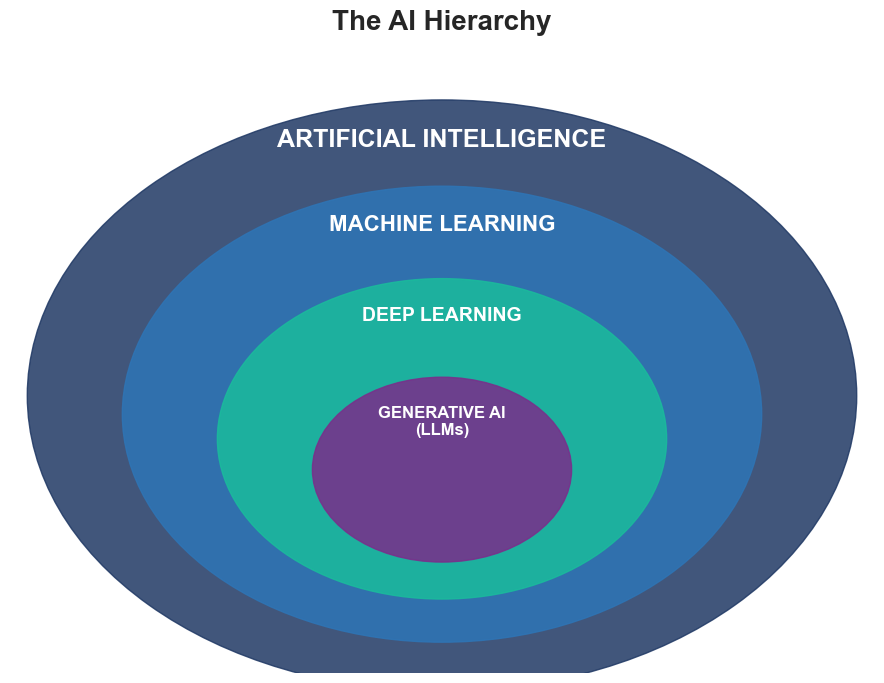

In [ ]:
# ── Visualizing the AI/ML/DL/GenAI Hierarchy ─────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_xlim(0, 10); ax.set_ylim(0, 10); ax.axis('off')
ax.set_facecolor('#f8f9fa')-circles = [
    (5, 4.5, 4.8, '#1F3864', 'ARTIFICIAL INTELLIGENCE', 'white', 18),
    (5, 4.2, 3.7, '#2E75B6', 'MACHINE LEARNING', 'white', 16),
    (5, 3.8, 2.6, '#1ABC9C', 'DEEP LEARNING', 'white', 14),
    (5, 3.3, 1.5, '#7B2D8B', 'GENERATIVE AI\n(LLMs)', 'white', 12),
]

for cx, cy, r, color, label, fc, fs in circles:
    circle = plt.Circle((cx, cy), r, color=color, fill=True, alpha=0.85)
    ax.add_patch(circle)
    ax.text(cx, cy + r - 0.45, label, ha='center', va='top',
            fontsize=fs, fontweight='bold', color=fc)

ax.set_title('The AI Hierarchy', fontsize=20, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


### 🔬 EXPERIMENT 1.1 — Classify these systems
Think about where each belongs in the hierarchy — run the cell to check!


In [4]:
systems = {
    'ChatGPT / Claude'        : 'Deep Learning + Generative AI (LLM)',
    'Email spam filter'        : 'Machine Learning (classification)',
    'Google Image Search'      : 'Deep Learning (CNN-based)',
    'Chess engine (rule-based)': 'AI (NOT ML — hardcoded rules)',
    'Netflix recommendations'  : 'Machine Learning (collaborative filtering)',
    'DALL-E / Midjourney'      : 'Deep Learning + Generative AI (diffusion)',
    'Weather forecast model'   : 'Machine Learning (regression/time-series)',
}

print('System Classification Guide:')
print('=' * 55)
for system, category in systems.items():
    print(f'  {system:<30} → {category}')


System Classification Guide:
  ChatGPT / Claude               → Deep Learning + Generative AI (LLM)
  Email spam filter              → Machine Learning (classification)
  Google Image Search            → Deep Learning (CNN-based)
  Chess engine (rule-based)      → AI (NOT ML — hardcoded rules)
  Netflix recommendations        → Machine Learning (collaborative filtering)
  DALL-E / Midjourney            → Deep Learning + Generative AI (diffusion)
  Weather forecast model         → Machine Learning (regression/time-series)


---
# 📌 SECTION 2: The Machine Learning Pipeline

## Why a Pipeline?
A pipeline is a **structured, repeatable sequence of steps** from raw data to deployed model.  
Skipping or reordering steps causes incorrect models and misleading results.

## The 5 Core Stages
```
 [1. Collect] ──► [2. Preprocess] ──► [3. Feature Eng] ──► [4. Train] ──► [5. Evaluate]
                                                                               │
                                                                          Good enough?
                                                                          ├── YES → Deploy
                                                                          └── NO  → Tune & Repeat
```

| Stage | What happens | Real-world analogy |
|-------|-------------|-------------------|
| **1. Data Collection** | Gather relevant data | Buying fresh ingredients |
| **2. Preprocessing** | Clean, fix, encode | Washing and chopping |
| **3. Feature Engineering** | Transform, create new features | Seasoning and mixing |
| **4. Model Training** | Algorithm learns patterns | Cooking on the stove |
| **5. Evaluation** | Measure performance on test data | Tasting and adjusting |


In [ ]:
# ── Visualizing the ML Pipeline ──────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(15, 4))
fig.patch.set_facecolor('#f0f4f8')

stages = [
    ('1\nData\nCollection', '#1F3864', '📦'),
    ('2\nData\nPreprocessing', '#2E75B6', '🧹'),
    ('3\nFeature\nEngineering', '#1ABC9C', '⚙️'),
    ('4\nModel\nTraining', '#27AE60', '🧠'),
    ('5\nEvaluation', '#E67E22', '📊'),
]

for i, (ax, (label, color, icon)) in enumerate(zip(axes, stages)):
    ax.set_facecolor(color)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.axis('off')
    ax.text(0.5, 0.65, icon, ha='center', va='center', fontsize=28)
    ax.text(0.5, 0.25, label, ha='center', va='center',
            fontsize=11, fontweight='bold', color='white', multialignment='center')
    if i < 4:
        ax.annotate('', xy=(1.12, 0.5), xytext=(1.0, 0.5),
                    arrowprops=dict(arrowstyle='->', color='#333', lw=2),
                    xycoords='axes fraction', textcoords='axes fraction')

fig.suptitle('The Machine Learning Pipeline', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
# 📌 SECTION 3: Data Concepts

## 3.1 Features vs Labels
- **Features (X)** — Inputs to the model (independent variables, predictors)
- **Labels (y)** — Output to predict (dependent variable, target)

## 3.2 Structured vs Unstructured Data
| Structured | Unstructured |
|-----------|-------------|
| Tables, CSV, SQL | Images, Audio, Video, Text |
| Clear rows & columns | No fixed format |
| Traditional ML works well | Needs DL / NLP |

## 3.3 Training vs Testing Data
- **Training set** — The model LEARNS from this (labels visible)
- **Test set** — The model is EVALUATED on this (labels hidden from model during training)

> ⚠️ **Critical rule:** The model must NEVER see test data during training.
> If it does → you get falsely optimistic performance (data leakage).


In [5]:
# ── Create a toy housing dataset to illustrate all concepts ──
np.random.seed(42)
n = 200

df = pd.DataFrame({
    'square_feet' : np.random.randint(500, 3500, n),
    'bedrooms'    : np.random.randint(1, 6, n),
    'bathrooms'   : np.random.randint(1, 4, n),
    'age_years'   : np.random.randint(1, 50, n),
    'neighborhood': np.random.choice(['Urban', 'Suburban', 'Rural'], n),
    'garage'      : np.random.choice(['Yes', 'No'], n),
})

# Generate price with some noise
df['price'] = (
    150 * df['square_feet']
    + 10000 * df['bedrooms']
    + 8000  * df['bathrooms']
    - 500   * df['age_years']
    + np.random.normal(0, 20000, n)
)
df['price'] = df['price'].clip(50000).round(-3)

print('📋 Dataset Shape:', df.shape)
print()
print('FEATURES (X) — What we use to predict:')
print('  ', [c for c in df.columns if c != 'price'])
print()
print('LABEL (y) — What we want to predict:')
print('   price')
print()
print('First 5 rows:')
df.head()


📋 Dataset Shape: (200, 7)

FEATURES (X) — What we use to predict:
   ['square_feet', 'bedrooms', 'bathrooms', 'age_years', 'neighborhood', 'garage']

LABEL (y) — What we want to predict:
   price

First 5 rows:


,square_feet,bedrooms,bathrooms,age_years,neighborhood,garage,price
0,1360,4,2,5,Urban,Yes,289000.0
1,1794,4,3,29,Urban,No,308000.0
2,1630,2,1,37,Suburban,No,234000.0
3,1595,3,3,38,Urban,No,272000.0
4,2138,1,3,19,Suburban,Yes,346000.0


In [6]:
# ── Understanding the data ───────────────────────────────────
print('Data Types:')
print(df.dtypes)
print()
print('Statistical Summary:')
df.describe().round(2)


Data Types:
square_feet       int32
bedrooms          int32
bathrooms         int32
age_years         int32
neighborhood     object
garage           object
price           float64
dtype: object

Statistical Summary:


,square_feet,bedrooms,bathrooms,age_years,price
count,200.00,200.00,200.00,200.00,200.00
mean,2064.93,2.90,1.90,24.73,341265.00
std,819.16,1.39,0.82,14.10,124608.11
min,521.00,1.00,1.00,1.00,82000.00
25%,1435.75,2.00,1.00,13.00,240000.00
50%,2017.50,3.00,2.00,26.00,340500.00
75%,2767.50,4.00,3.00,36.25,451750.00
max,3477.00,5.00,3.00,49.00,571000.00


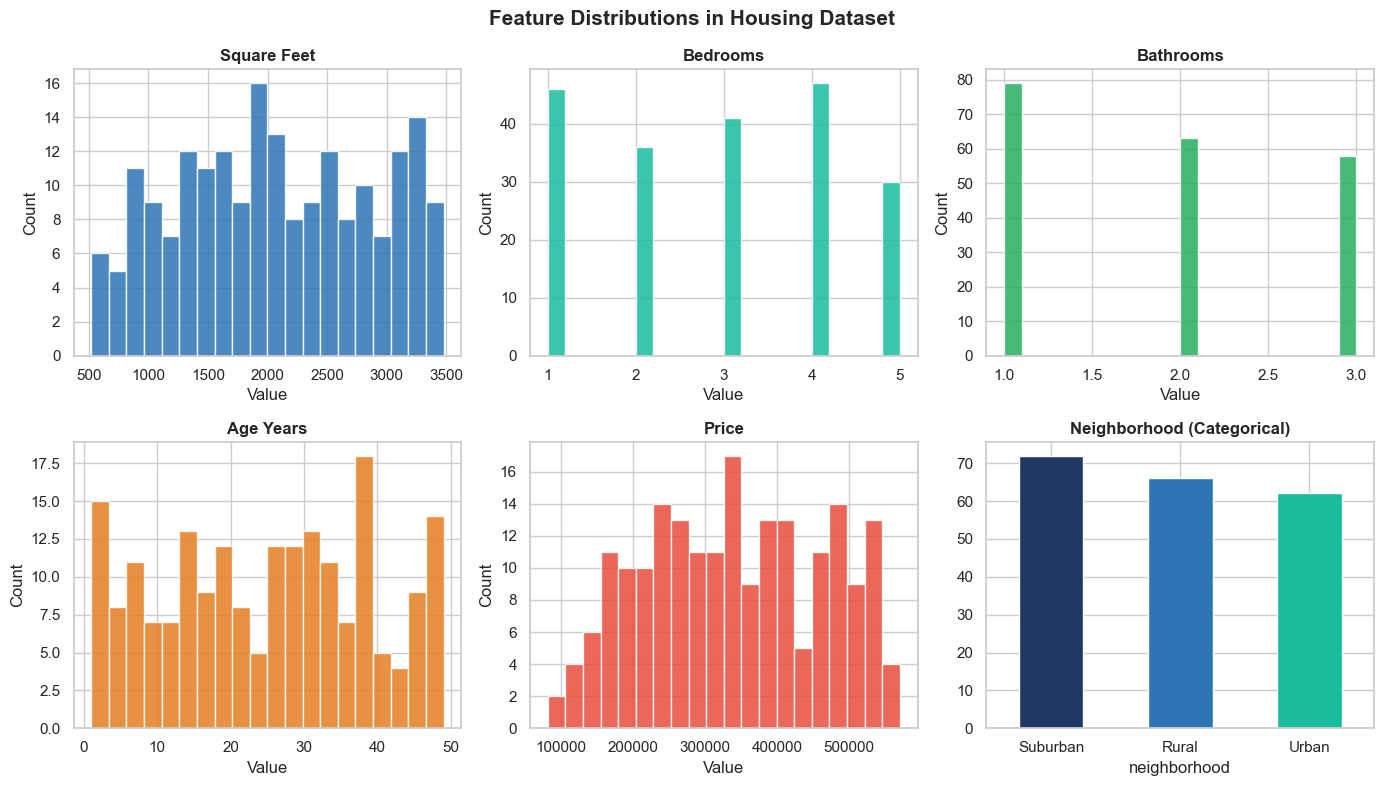

In [7]:
# ── Visualize feature distributions ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions in Housing Dataset', fontsize=15, fontweight='bold')

cols = ['square_feet', 'bedrooms', 'bathrooms', 'age_years', 'price']
colors = ['#2E75B6', '#1ABC9C', '#27AE60', '#E67E22', '#E74C3C']

for ax, col, color in zip(axes.flat[:5], cols, colors):
    ax.hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Count')

# Categorical: neighborhood
df['neighborhood'].value_counts().plot(kind='bar', ax=axes[1,2],
    color=['#1F3864','#2E75B6','#1ABC9C'], edgecolor='white')
axes[1,2].set_title('Neighborhood (Categorical)', fontweight='bold')
axes[1,2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()


---
# 📌 SECTION 4: Train-Test Split — Deep Dive

## Why Split Data?
The goal of ML is to make accurate predictions on **NEW, UNSEEN data**.  
If we train and test on the same data, the model just memorizes — it tells us nothing about real-world performance.

## Split Ratios
| Split | When to use |
|-------|------------|
| 70/30 | General purpose, medium datasets |
| 80/20 | Small datasets, need more training data |
| 60/20/20 | Train / Validation / Test (with hyperparameter tuning) |
| K-Fold CV | Small datasets, get reliable estimate |

## The `random_state` Parameter
Ensures your split is **reproducible** — same rows go to train/test every run.  
Use any integer (42 is convention, but it doesn't matter).


In [8]:
# ── Perform Train-Test Split ─────────────────────────────────
# Select numeric features only for now
feature_cols = ['square_feet', 'bedrooms', 'bathrooms', 'age_years']
X = df[feature_cols]
y = df['price']

# 70/30 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,     # 30% goes to test
    random_state=42     # reproducibility
)

print('📊 Data Split Summary')
print('=' * 40)
print(f'  Total samples   : {len(X)}')
print(f'  Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)')
print(f'  Testing  samples: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)')
print()
print('Training set y stats:')
print(f'  Mean price: ${y_train.mean():,.0f}')
print('Testing set y stats:')
print(f'  Mean price: ${y_test.mean():,.0f}')
print('  (Both means should be similar — good split!)')


📊 Data Split Summary
  Total samples   : 200
  Training samples: 140 (70%)
  Testing  samples: 60 (30%)

Training set y stats:
  Mean price: $341,279
Testing set y stats:
  Mean price: $341,233
  (Both means should be similar — good split!)


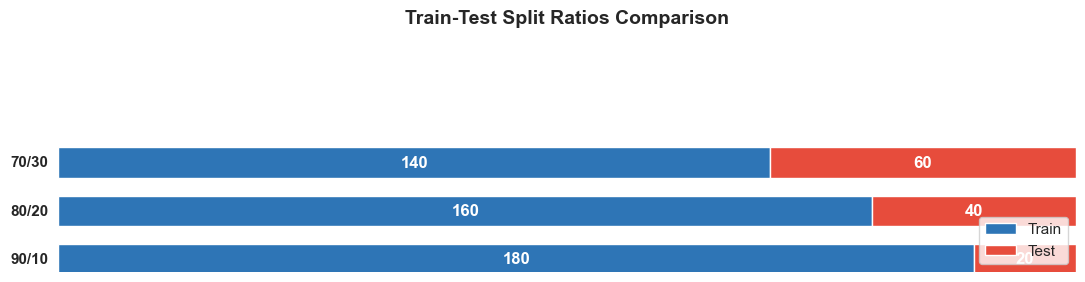

In [9]:
# 🔬 EXPERIMENT 4.1 — Try different split ratios
# Change test_size and observe how training/testing sizes change

fig, ax = plt.subplots(figsize=(11, 3))
ax.set_xlim(0, 200); ax.set_ylim(0, 1); ax.axis('off')

splits = [('70/30', 0.30), ('80/20', 0.20), ('90/10', 0.10)]
for i, (label, ts) in enumerate(splits):
    Xtr, Xte, _, _ = train_test_split(X, y, test_size=ts, random_state=42)
    bar_y = 0.5 - i*0.22
    # Train bar
    ax.barh(bar_y, len(Xtr), color='#2E75B6', height=0.14, label='Train' if i==0 else '')
    # Test bar
    ax.barh(bar_y, len(Xte), left=len(Xtr), color='#E74C3C', height=0.14, label='Test' if i==0 else '')
    ax.text(-2, bar_y, label, ha='right', va='center', fontweight='bold', fontsize=11)
    ax.text(len(Xtr)/2, bar_y, f'{len(Xtr)}', ha='center', va='center', color='white', fontweight='bold')
    ax.text(len(Xtr)+len(Xte)/2, bar_y, f'{len(Xte)}', ha='center', va='center', color='white', fontweight='bold')

ax.legend(loc='lower right', fontsize=11)
ax.set_title('Train-Test Split Ratios Comparison', fontsize=14, fontweight='bold', y=1.1)
plt.tight_layout()
plt.show()


In [10]:
# ── Cross-Validation Introduction ────────────────────────────
from sklearn.model_selection import KFold, cross_val_score

model_cv = LinearRegression()
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(model_cv, X, y, cv=kf, scoring='r2')

print('5-Fold Cross-Validation Results:')
print('=' * 40)
for i, score in enumerate(cv_scores, 1):
    bar = '█' * int(score * 30)
    print(f'  Fold {i}: R² = {score:.4f}  {bar}')
print(f'  Mean R²  : {cv_scores.mean():.4f}')
print(f'  Std Dev  : {cv_scores.std():.4f}')
print()
print('Lower std dev = more stable model across different data subsets')


5-Fold Cross-Validation Results:
  Fold 1: R² = 0.9720  █████████████████████████████
  Fold 2: R² = 0.9742  █████████████████████████████
  Fold 3: R² = 0.9714  █████████████████████████████
  Fold 4: R² = 0.9694  █████████████████████████████
  Fold 5: R² = 0.9754  █████████████████████████████
  Mean R²  : 0.9725
  Std Dev  : 0.0021

Lower std dev = more stable model across different data subsets


---
# 📌 SECTION 5: Data Preprocessing

## The Golden Rules
1. **Always clean BEFORE training**
2. **Fit preprocessing on TRAIN only, transform both train and test**
3. **Never let test data influence your preprocessing** (data leakage)

## 5.1 Handling Missing Values
| Strategy | When | Code |
|---------|------|------|
| Drop rows | Missing < 5%, random | `df.dropna()` |
| Fill with mean | Numerical, symmetric | `df.fillna(df.mean())` |
| Fill with median | Numerical, skewed/outliers | `df.fillna(df.median())` |
| Fill with mode | Categorical | `df.fillna(df.mode()[0])` |
| Forward fill | Time series | `df.fillna(method='ffill')` |

## 5.2 Encoding Categorical Variables
- **Label Encoding** — for ordinal data (Low=0, Medium=1, High=2)
- **One-Hot Encoding** — for nominal data (Red, Blue, Green → 3 binary columns)

## 5.3 Feature Scaling
| Method | Formula | Best For |
|--------|---------|---------|
| Min-Max Normalization | (x - min)/(max - min) → [0,1] | KNN, Neural Nets |
| Standardization (Z-score) | (x - mean)/std → mean=0, std=1 | Linear Regression, SVM |


In [11]:
# ── Introduce missing values artificially to practice ─────────
df_messy = df.copy()
np.random.seed(0)

# Add 15 missing values in square_feet
missing_idx = np.random.choice(df_messy.index, 15, replace=False)
df_messy.loc[missing_idx, 'square_feet'] = np.nan

# Add 10 missing in bedrooms
missing_idx2 = np.random.choice(df_messy.index, 10, replace=False)
df_messy.loc[missing_idx2, 'bedrooms'] = np.nan

print('Missing Value Count:')
print(df_messy.isnull().sum())
print(f'\nTotal missing: {df_messy.isnull().sum().sum()}')


Missing Value Count:
square_feet     15
bedrooms        10
bathrooms        0
age_years        0
neighborhood     0
garage           0
price            0
dtype: int64

Total missing: 25


In [12]:
# ── Fix missing values ───────────────────────────────────────
df_clean = df_messy.copy()

# Strategy: fill with median (robust to outliers)
df_clean['square_feet'] = df_clean['square_feet'].fillna(df_clean['square_feet'].median())
df_clean['bedrooms']    = df_clean['bedrooms'].fillna(df_clean['bedrooms'].median())

print('After Fixing:')
print(df_clean.isnull().sum())
print('✅ No more missing values!')


After Fixing:
square_feet     0
bedrooms        0
bathrooms       0
age_years       0
neighborhood    0
garage          0
price           0
dtype: int64
✅ No more missing values!


In [13]:
# ── Encoding Categorical Variables ───────────────────────────
print('Unique neighborhoods:', df_clean['neighborhood'].unique())
print('Unique garage values:', df_clean['garage'].unique())
print()

# One-Hot Encoding for neighborhood (nominal — no order)
df_encoded = pd.get_dummies(df_clean, columns=['neighborhood'], prefix='loc', drop_first=False)

# Label Encoding for garage (binary)
df_encoded['garage_bin'] = (df_encoded['garage'] == 'Yes').astype(int)
df_encoded.drop('garage', axis=1, inplace=True)

print('Columns after encoding:', list(df_encoded.columns))
print()
df_encoded.head(3)


Unique neighborhoods: ['Urban' 'Suburban' 'Rural']
Unique garage values: ['Yes' 'No']

Columns after encoding: ['square_feet', 'bedrooms', 'bathrooms', 'age_years', 'price', 'loc_Rural', 'loc_Suburban', 'loc_Urban', 'garage_bin']



,square_feet,bedrooms,bathrooms,age_years,price,loc_Rural,loc_Suburban,loc_Urban,garage_bin
0,1360.0,4.0,2,5,289000.0,False,False,True,1
1,1794.0,4.0,3,29,308000.0,False,False,True,0
2,1630.0,2.0,1,37,234000.0,False,True,False,0


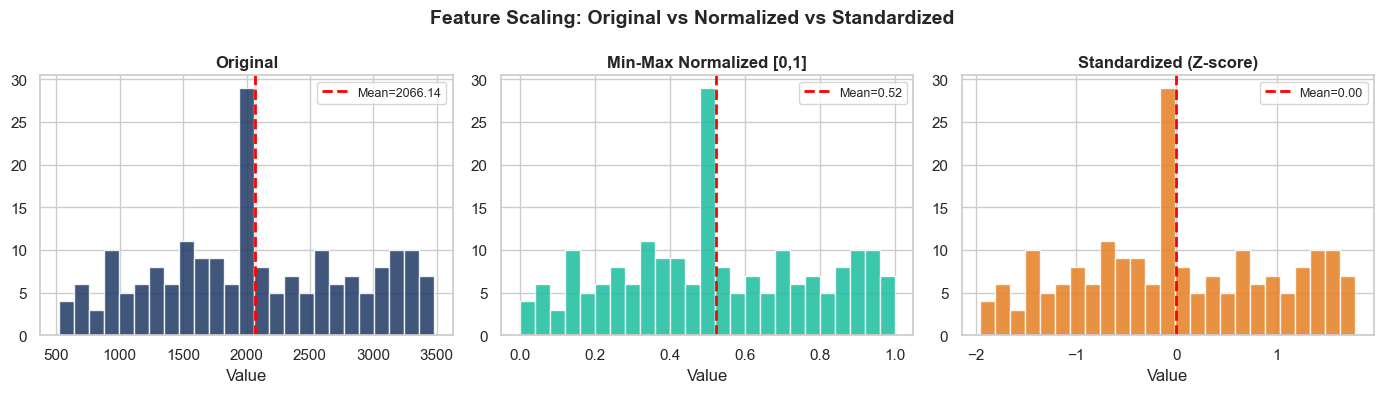

Original    — min: 521, max: 3477, mean: 2066
Min-Max     — min: 0.000, max: 1.000, mean: 0.523
Standardized— min: -1.954, max: 1.784, mean: 0.000


In [14]:
# ── Feature Scaling — Side by Side ──────────────────────────
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Use square_feet as example
x_orig = df_clean[['square_feet']].values

minmax = MinMaxScaler()
stdsc  = StandardScaler()

x_mm = minmax.fit_transform(x_orig)
x_st = stdsc.fit_transform(x_orig)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, data, title, color in zip(axes,
    [x_orig, x_mm, x_st],
    ['Original', 'Min-Max Normalized [0,1]', 'Standardized (Z-score)'],
    ['#1F3864', '#1ABC9C', '#E67E22']):
    ax.hist(data.flatten(), bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Value')
    mu = data.mean(); sd = data.std()
    ax.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'Mean={mu:.2f}')
    ax.legend(fontsize=9)

plt.suptitle('Feature Scaling: Original vs Normalized vs Standardized', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Original    — min: {x_orig.min():.0f}, max: {x_orig.max():.0f}, mean: {x_orig.mean():.0f}')
print(f'Min-Max     — min: {x_mm.min():.3f}, max: {x_mm.max():.3f}, mean: {x_mm.mean():.3f}')
print(f'Standardized— min: {x_st.min():.3f}, max: {x_st.max():.3f}, mean: {x_st.mean():.3f}')


---
# 📌 SECTION 6: Supervised Learning & Regression

## Supervised vs Unsupervised
| Type | Labels? | Goal | Examples |
|------|---------|------|---------|
| **Supervised** | ✅ Yes | Learn f(X) → y | Regression, Classification |
| **Unsupervised** | ❌ No | Find patterns | Clustering, PCA |
| **Semi-supervised** | Partial | Use few labels | Label propagation |

## Regression vs Classification
| | Regression | Classification |
|-|-----------|---------------|
| **Output** | Continuous number | Discrete category |
| **Example** | Predict house price ($350,000) | Predict spam (Yes/No) |
| **Metrics** | MAE, RMSE, R² | Accuracy, F1, AUC |
| **Algorithm (simple)** | Linear Regression | Logistic Regression |


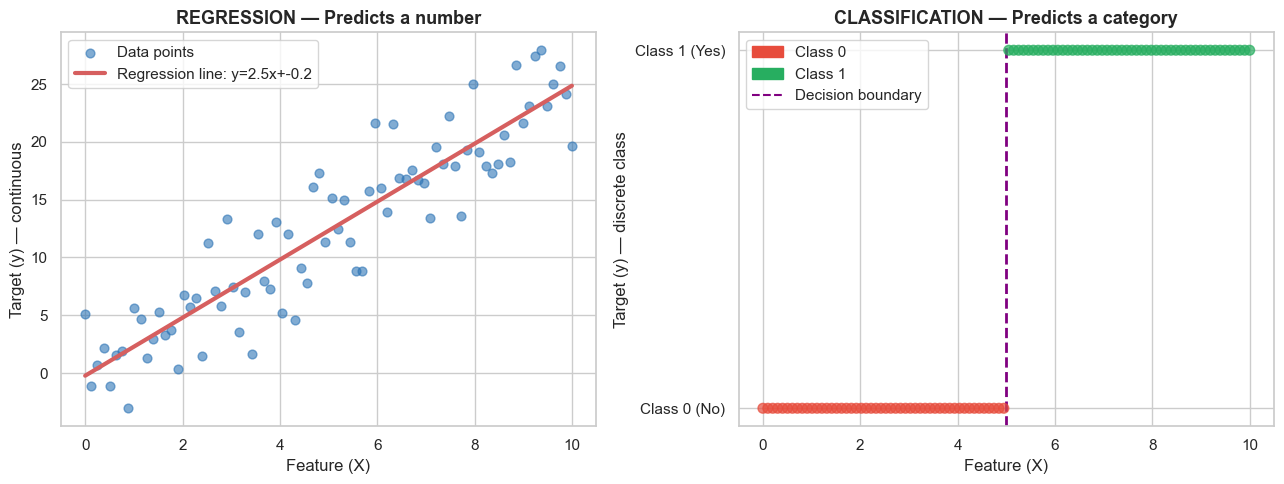

In [15]:
# ── Visualize Regression vs Classification ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Regression side
np.random.seed(7)
x_reg = np.linspace(0, 10, 80)
y_reg = 2.5 * x_reg + np.random.normal(0, 3, 80)
axes[0].scatter(x_reg, y_reg, color='#2E75B6', alpha=0.6, s=40, label='Data points')
m, b = np.polyfit(x_reg, y_reg, 1)
axes[0].plot(x_reg, m*x_reg+b, 'r-', linewidth=3, label=f'Regression line: y={m:.1f}x+{b:.1f}')
axes[0].set_title('REGRESSION — Predicts a number', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Feature (X)'); axes[0].set_ylabel('Target (y) — continuous')
axes[0].legend()

# Classification side
x_cl = np.linspace(0, 10, 100)
y_cl = (x_cl > 5).astype(int) + np.random.normal(0, 0.15, 100)
y_cl_label = (y_cl > 0.5).astype(int)
colors_cl = ['#E74C3C' if c==0 else '#27AE60' for c in y_cl_label]
axes[1].scatter(x_cl, y_cl_label, c=colors_cl, s=50, alpha=0.7, zorder=3)
axes[1].axvline(5, color='purple', linestyle='--', linewidth=2, label='Decision boundary')
axes[1].set_yticks([0, 1]); axes[1].set_yticklabels(['Class 0 (No)', 'Class 1 (Yes)'])
axes[1].set_title('CLASSIFICATION — Predicts a category', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Feature (X)'); axes[1].set_ylabel('Target (y) — discrete class')
axes[1].legend()
p0 = mpatches.Patch(color='#E74C3C', label='Class 0'); p1 = mpatches.Patch(color='#27AE60', label='Class 1')
axes[1].legend(handles=[p0, p1, plt.Line2D([0],[0], color='purple', linestyle='--', label='Decision boundary')])

plt.tight_layout()
plt.show()


---
# 📌 SECTION 7: Simple Linear Regression

## The Equation
$$y = \beta_0 + \beta_1 x$$

- $\beta_0$ = **intercept** (value of y when x=0)
- $\beta_1$ = **slope / coefficient** (change in y per 1-unit increase in x)

## How it Learns: Ordinary Least Squares (OLS)
Find $\beta_0, \beta_1$ that minimize the **Mean Squared Error**:
$$MSE = \frac{1}{n} \sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

## When to Use / Avoid
| ✅ Use When | ❌ Avoid When |
|-----------|-------------|
| Relationship is roughly linear | Data has clear curves |
| Interpretability matters | Complex non-linear patterns |
| Quick baseline needed | Many irrelevant features |
| One main predictor | Image/text/audio tasks |


In [16]:
# ── Simple Linear Regression: square_feet → price ────────────
X_simple = df[['square_feet']]
y_target  = df['price']

# Split
X_tr, X_te, y_tr, y_te = train_test_split(X_simple, y_target, test_size=0.3, random_state=42)

# Scale
sc = StandardScaler()
X_tr_sc = sc.fit_transform(X_tr)
X_te_sc = sc.transform(X_te)

# Train
slr = LinearRegression()
slr.fit(X_tr_sc, y_tr)

# Predict
y_pred_slr = slr.predict(X_te_sc)

print('Simple Linear Regression Results')
print('=' * 45)
print(f'  Intercept (β₀) : {slr.intercept_:>12,.2f}')
print(f'  Coefficient (β₁): {slr.coef_[0]:>12,.2f}')
print()
print('Equation: Price = {:.0f} + {:.0f} × (scaled_sqft)'.format(
    slr.intercept_, slr.coef_[0]))
print()

mae  = mean_absolute_error(y_te, y_pred_slr)
rmse = np.sqrt(mean_squared_error(y_te, y_pred_slr))
r2   = r2_score(y_te, y_pred_slr)
print(f'  MAE  : ${mae:>10,.2f}')
print(f'  RMSE : ${rmse:>10,.2f}')
print(f'  R²   : {r2:>12.4f}  ({r2*100:.1f}% variance explained)')


Simple Linear Regression Results
  Intercept (β₀) :   341,278.57
  Coefficient (β₁):   124,927.48

Equation: Price = 341279 + 124927 × (scaled_sqft)

  MAE  : $ 21,796.93
  RMSE : $ 26,593.25
  R²   :       0.9477  (94.8% variance explained)


In [ ]:
# ── Visualize the Regression Line ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter + regression line (original scale)
axes[0].scatter(X_te['square_feet'], y_te, alpha=0.5, color='#2E75B6', s=40, label='Actual')
axes[0].scatter(X_te['square_feet'], y_pred_slr, alpha=0.5, color='#E74C3C', s=40, label='Predicted')

# Plot regression line
x_line = np.linspace(X_te['square_feet'].min(), X_te['square_feet'].max(), 100).reshape(-1,1)
x_line_sc = sc.transform(x_line)
y_line = slr.predict(x_line_sc)
axes[0].plot(x_line, y_line, 'r-', linewidth=2.5, label='Regression Line')

axes[0].set_xlabel('Square Feet', fontsize=12)
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].set_title('Simple Linear Regression\nSquare Feet → House Price', fontweight='bold')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Right: Actual vs Predicted
axes[1].scatter(y_te, y_pred_slr, alpha=0.5, color='#27AE60', s=40)
perfect = [y_te.min(), y_te.max()]
axes[1].plot(perfect, perfect, 'r--', linewidth=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Price ($)', fontsize=12)
axes[1].set_ylabel('Predicted Price ($)', fontsize=12)
axes[1].set_title(f'Actual vs Predicted\nR² = {r2:.4f}', fontweight='bold')
axes[1].legend()
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e5:.1f}K'))
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e5:.1f}K'))

plt.tight_layout()
plt.show()


In [17]:
# 🔬 EXPERIMENT 7.1 — Manual Prediction
# What does our model predict for a 2,000 sq ft house?

sqft_new = 2000  # 🔬 Change this value and re-run!

x_new = np.array([[sqft_new]])
x_new_sc = sc.transform(x_new)
price_predicted = slr.predict(x_new_sc)[0]

print(f'For a house with {sqft_new:,} sq ft:')
print(f'Predicted Price: ${price_predicted:,.0f}')
print()
print('Try different values for sqft_new and re-run!')
print('Values to try: 800, 1200, 1800, 2500, 3200')


For a house with 2,000 sq ft:
Predicted Price: $331,602

Try different values for sqft_new and re-run!
Values to try: 800, 1200, 1800, 2500, 3200


---
# 📌 SECTION 8: Multiple Linear Regression

## The Equation
$$y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_3 + \cdots + \beta_n x_n$$

Each coefficient $\beta_i$ = change in y for 1-unit increase in $x_i$, **holding all others constant**.

## Key Concept: Multicollinearity
> When two features are strongly correlated with each other, coefficients become **unstable and uninterpretable**.
> Always check the **correlation matrix** before building a multiple regression model.


In [18]:
# ── Multiple Linear Regression ───────────────────────────────
feature_cols = ['square_feet', 'bedrooms', 'bathrooms', 'age_years']
X_multi = df[feature_cols]
y_multi = df['price']

# Split
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(X_multi, y_multi, test_size=0.3, random_state=42)

# Scale
sc_multi = StandardScaler()
Xm_tr_sc = sc_multi.fit_transform(Xm_tr)
Xm_te_sc = sc_multi.transform(Xm_te)

# Train
mlr = LinearRegression()
mlr.fit(Xm_tr_sc, ym_tr)

# Predict
ym_pred = mlr.predict(Xm_te_sc)

print('Multiple Linear Regression — Coefficients')
print('=' * 50)
print(f'  Intercept: {mlr.intercept_:>12,.2f}')
for feat, coef in zip(feature_cols, mlr.coef_):
    direction = '▲ increases price' if coef > 0 else '▼ decreases price'
    print(f'  {feat:<15}: {coef:>10,.2f}  ({direction})')
print()

mae_m  = mean_absolute_error(ym_te, ym_pred)
rmse_m = np.sqrt(mean_squared_error(ym_te, ym_pred))
r2_m   = r2_score(ym_te, ym_pred)
print(f'  MAE  : ${mae_m:>10,.2f}')
print(f'  RMSE : ${rmse_m:>10,.2f}')
print(f'  R²   : {r2_m:>12.4f}  ({r2_m*100:.1f}% variance explained)')
print()
print(f'Simple LR R²:   {r2:.4f}')
print(f'Multiple LR R²: {r2_m:.4f}  ← Better with more features!')


Multiple Linear Regression — Coefficients
  Intercept:   341,278.57
  square_feet    : 124,598.73  (▲ increases price)
  bedrooms       :  14,403.14  (▲ increases price)
  bathrooms      :   4,564.48  (▲ increases price)
  age_years      :  -7,482.33  (▼ decreases price)

  MAE  : $ 16,356.65
  RMSE : $ 20,066.03
  R²   :       0.9702  (97.0% variance explained)

Simple LR R²:   0.9477
Multiple LR R²: 0.9702  ← Better with more features!


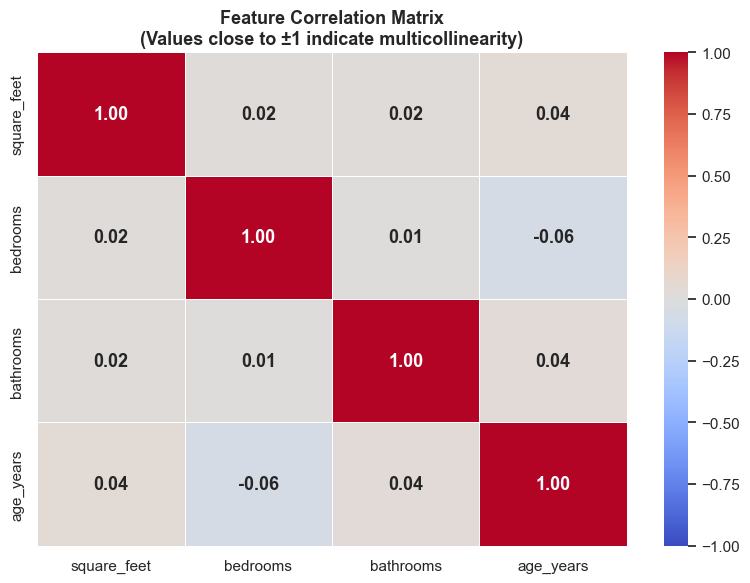

Interpretation:
  |corr| > 0.8 → HIGH multicollinearity risk
  |corr| 0.5-0.8 → Moderate — watch out
  |corr| < 0.5 → Generally safe


In [19]:
# ── Check for Multicollinearity — Correlation Matrix ─────────
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax, linewidths=0.5,
            annot_kws={'size':13, 'weight':'bold'})
ax.set_title('Feature Correlation Matrix\n(Values close to ±1 indicate multicollinearity)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

print('Interpretation:')
print('  |corr| > 0.8 → HIGH multicollinearity risk')
print('  |corr| 0.5-0.8 → Moderate — watch out')
print('  |corr| < 0.5 → Generally safe')


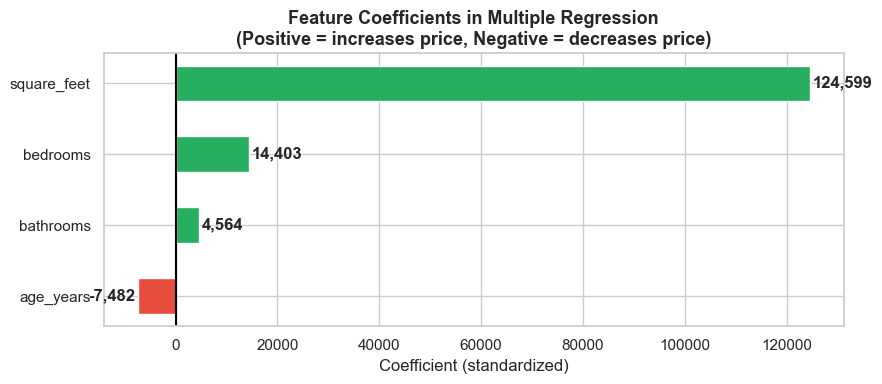

In [20]:
# ── Coefficient Importance Bar Chart ─────────────────────────
coef_df = pd.DataFrame({
    'Feature'    : feature_cols,
    'Coefficient': mlr.coef_
}).sort_values('Coefficient', ascending=True)

colors_bar = ['#E74C3C' if c < 0 else '#27AE60' for c in coef_df['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors_bar, edgecolor='white', height=0.5)
ax.axvline(0, color='black', linewidth=1.5)
ax.set_xlabel('Coefficient (standardized)', fontsize=12)
ax.set_title('Feature Coefficients in Multiple Regression\n(Positive = increases price, Negative = decreases price)',
             fontweight='bold', fontsize=13)

for bar, val in zip(bars, coef_df['Coefficient']):
    ax.text(val + (500 if val > 0 else -500), bar.get_y()+bar.get_height()/2,
            f'{val:,.0f}', va='center', ha='left' if val>0 else 'right', fontweight='bold')

plt.tight_layout()
plt.show()


---
# 📌 SECTION 9: Model Evaluation & Diagnostics

## Metrics Recap
| Metric | Formula | Units | Ideal |
|--------|---------|-------|-------|
| MAE | Mean\|actual-predicted\| | Same as y | Close to 0 |
| MSE | Mean(actual-predicted)² | y² | Close to 0 |
| RMSE | √MSE | Same as y | Close to 0 |
| R² | 1 - SS_res/SS_tot | Unitless | Close to 1 |

## Overfitting vs Underfitting
```
Overfitting:   Train R² = 0.99, Test R² = 0.55  ← Gap is the problem!
Good Fit:      Train R² = 0.88, Test R² = 0.85  ← Small gap, both good
Underfitting:  Train R² = 0.45, Test R² = 0.42  ← Both bad
```


In [21]:
# ── Compare All Models ───────────────────────────────────────
results = {
    'Simple LR (sqft only)': {
        'train_r2': r2_score(y_tr, slr.predict(X_tr_sc)),
        'test_r2' : r2,
        'test_rmse': np.sqrt(mean_squared_error(y_te, y_pred_slr)),
        'test_mae' : mean_absolute_error(y_te, y_pred_slr)
    },
    'Multiple LR (4 features)': {
        'train_r2': r2_score(ym_tr, mlr.predict(Xm_tr_sc)),
        'test_r2' : r2_m,
        'test_rmse': rmse_m,
        'test_mae' : mae_m
    }
}

print('Model Comparison')
print('=' * 60)
print(f'{"Model":<30} {"Train R²":>8} {"Test R²":>8} {"RMSE":>12} {"MAE":>12}')
print('-' * 60)
for name, m in results.items():
    gap = m['train_r2'] - m['test_r2']
    flag = '⚠️  overfit?' if gap > 0.1 else '✅'
    print(f'{name:<30} {m["train_r2"]:>8.4f} {m["test_r2"]:>8.4f} '",
          f'${m["test_rmse"]:>10,.0f} ${m["test_mae"]:>10,.0f}  {flag}')


SyntaxError: unterminated string literal (detected at line 24) (2151777863.py, line 24)

In [ ]:
# ── Residual Analysis ────────────────────────────────────────
residuals = ym_te.values - ym_pred

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Residual Diagnostics — Multiple Linear Regression', fontsize=14, fontweight='bold')

# 1: Residuals vs Fitted
axes[0].scatter(ym_pred, residuals, alpha=0.5, color='#2E75B6', s=35)
axes[0].axhline(0, color='red', linewidth=2, linestyle='--')
axes[0].set_xlabel('Fitted Values'); axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Fitted\n(Should be random scatter around 0)')

# 2: Residual histogram
axes[1].hist(residuals, bins=25, color='#1ABC9C', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', linewidth=2, linestyle='--')
axes[1].set_xlabel('Residual'); axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution\n(Should be roughly normal)')

# 3: Q-Q plot
from scipy import stats
stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot\n(Points on line = normal residuals)', fontweight='bold')
axes[2].get_lines()[0].set(markersize=4, alpha=0.5)
axes[2].get_lines()[1].set(color='red', linewidth=2)

plt.tight_layout()
plt.show()

print(f'Residuals — Mean: {residuals.mean():,.0f} (should be ≈ 0)')
print(f'Residuals — Std:  ${residuals.std():,.0f}')


In [ ]:
# 🔬 EXPERIMENT 9.1 — Overfitting vs Underfitting Demo
# We simulate by varying how many polynomial features we use

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

np.random.seed(42)
x_exp = np.linspace(0, 5, 50).reshape(-1,1)
y_exp = 2*x_exp.flatten()**2 - 3*x_exp.flatten() + np.random.normal(0, 2, 50)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
degrees = [1, 2, 15]
labels  = ['Underfitting (degree=1)', 'Good Fit (degree=2)', 'Overfitting (degree=15)']
colors_fit = ['#E67E22', '#27AE60', '#E74C3C']

for ax, deg, label, color in zip(axes, degrees, labels, colors_fit):
    pipe = Pipeline([('poly', PolynomialFeatures(deg)), ('lr', LinearRegression())])
    pipe.fit(x_exp, y_exp)
    x_plot = np.linspace(0, 5, 300).reshape(-1,1)
    y_plot = pipe.predict(x_plot)
    ax.scatter(x_exp, y_exp, color='#2E75B6', s=40, alpha=0.7, zorder=3)
    ax.plot(x_plot, y_plot, color=color, linewidth=2.5)
    r2_tr = r2_score(y_exp, pipe.predict(x_exp))
    ax.set_title(f'{label}\nTrain R² = {r2_tr:.3f}', fontweight='bold', fontsize=11)
    ax.set_ylim(-5, 50)

plt.suptitle('Overfitting vs Underfitting Demonstration', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
# 📌 SECTION 10: Complete End-to-End Pipeline
Putting it all together — from raw CSV to evaluated model using **sklearn Pipeline**.

Using the real **California Housing Dataset** from sklearn.


In [ ]:
# ── Load Real Dataset ────────────────────────────────────────
housing = fetch_california_housing(as_frame=True)
df_ca = housing.frame

print('California Housing Dataset')
print('=' * 45)
print(f'  Shape: {df_ca.shape}')
print(f'  Features: {list(housing.feature_names)}')
print(f'  Target: MedHouseVal (median house value in $100k)')
print()
print('Missing values:', df_ca.isnull().sum().sum())
print()
df_ca.describe().round(2)


In [ ]:
# ── Full Pipeline ────────────────────────────────────────────
X_ca = df_ca.drop('MedHouseVal', axis=1)
y_ca = df_ca['MedHouseVal']

# Split
Xca_tr, Xca_te, yca_tr, yca_te = train_test_split(
    X_ca, y_ca, test_size=0.2, random_state=42)

# Build sklearn Pipeline (prevents data leakage automatically!)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  LinearRegression())
])

# Train
pipeline.fit(Xca_tr, yca_tr)

# Evaluate
yca_pred_tr = pipeline.predict(Xca_tr)
yca_pred_te = pipeline.predict(Xca_te)

print('California Housing — Multiple Linear Regression')
print('=' * 55)
print(f'  Train R²:  {r2_score(yca_tr, yca_pred_tr):.4f}')
print(f'  Test  R²:  {r2_score(yca_te, yca_pred_te):.4f}')
print(f'  Test RMSE: {np.sqrt(mean_squared_error(yca_te, yca_pred_te)):.4f} (×$100k)')
print(f'  Test MAE:  {mean_absolute_error(yca_te, yca_pred_te):.4f} (×$100k)')

coef_df_ca = pd.DataFrame({
    'Feature': housing.feature_names,
    'Coefficient': pipeline.named_steps['model'].coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print()
print('Feature Importance (by |coefficient|):')
print(coef_df_ca.to_string(index=False))


In [ ]:
# ── Final Visualization ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Actual vs Predicted
axes[0].scatter(yca_te, yca_pred_te, alpha=0.2, s=15, color='#2E75B6')
lims = [yca_te.min(), yca_te.max()]
axes[0].plot(lims, lims, 'r--', linewidth=2, label='Perfect')
axes[0].set_xlabel('Actual Value (×$100k)'); axes[0].set_ylabel('Predicted Value (×$100k)')
axes[0].set_title(f'California Housing\nActual vs Predicted  (R²={r2_score(yca_te,yca_pred_te):.3f})', fontweight='bold')
axes[0].legend()

# Feature coefficients
colors_ca = ['#E74C3C' if c<0 else '#27AE60' for c in coef_df_ca['Coefficient']]
axes[1].barh(coef_df_ca['Feature'], coef_df_ca['Coefficient'], color=colors_ca, edgecolor='white')
axes[1].axvline(0, color='black', lw=1.5)
axes[1].set_xlabel('Coefficient (standardized)')
axes[1].set_title('Feature Coefficients\n(Green=positive effect, Red=negative)', fontweight='bold')

plt.tight_layout()
plt.show()


---
# 🏆 Day 1 Complete — Summary Cheatsheet

## Key Formulas
| Concept | Formula |
|---------|---------|
| Simple Linear Regression | y = β₀ + β₁x |
| Multiple Linear Regression | y = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ |
| MAE | Mean(|actual - predicted|) |
| MSE | Mean((actual - predicted)²) |
| RMSE | √MSE |
| R² | 1 - (SS_residual / SS_total) |
| Normalization | (x - min) / (max - min) |
| Standardization | (x - mean) / std |

## Decision Guide
```
Problem type?
├─ Predict a NUMBER → Regression
│    └─ One feature? → Simple Linear Regression
│    └─ Many features? → Multiple Linear Regression
└─ Predict a CATEGORY → Classification (Day 2!)
```

## Final Checklist
- [x] Explain AI vs ML vs DL vs GenAI + where LLMs fit
- [x] Describe the 5-stage ML pipeline
- [x] Understand features, labels, structured vs unstructured data
- [x] Perform train-test split correctly (fit scaler on train only!)
- [x] Handle missing values, encode categoricals, scale features
- [x] Build Simple and Multiple Linear Regression
- [x] Evaluate with MAE, RMSE, R²
- [x] Diagnose overfitting vs underfitting

---
> **Next:** Day 2 — Classification, Logistic Regression & Decision Trees 🌳


In [1]:
!pip install seaborn